# Fraud Detection System
This project implements a fraud detection system using the Credit Card Fraud Detection dataset. The dataset contains anonymized financial transaction data, with each transaction labeled as either fraudulent (1) or legitimate (0). Due to the severe imbalance between fraudulent and legitimate transactions, the project focuses not only on building predictive models but also on proper data preprocessing and evaluation to handle class imbalance effectively. The end goal is to create a Python-based system that accurately detects fraudulent transactions and includes an interactive testing interface.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

## Step 1: Importing the Dataset

The dataset used in this project is loaded into a Pandas DataFrame using `pd.read_csv()`. This dataset includes features named `V1` to `V28` which are the result of PCA transformations to maintain confidentiality, along with `Time`, `Amount`, and the `Class` column which indicates whether a transaction is fraudulent. Loading the dataset is the first crucial step to make it accessible for preprocessing, training, and evaluation.

In [2]:
ds = pd.read_csv('creditcard.csv')

In [3]:
ds.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
ds['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Step 2: Exploring Class Imbalance

A significant issue with fraud detection datasets is the **high class imbalance** — only a tiny percentage of transactions are labeled as fraudulent. To explore this, the value counts of the `Class` column are visualized using count plots. The majority class (legitimate transactions) dominates the data, highlighting the need for resampling techniques to balance the dataset before training machine learning models.|

## Step 3: Data Preprocessing

In this step, we separate the features (`X`) from the target (`y`). The `Class` column is dropped from the dataset to form the features matrix `X`, while it is retained as the target variable `y`. This separation is necessary for training any machine learning model, where `X` contains the input attributes and `y` contains the ground truth labels. After that, the data is split into training and testing sets using `train_test_split()` with stratification, ensuring that the same class ratio is preserved in both sets.

In [5]:
X = ds.drop('Class', axis=1)
y = ds['Class']

## Step 4: Handling Class Imbalance

To address the imbalance in the dataset, the SMOTE (Synthetic Minority Oversampling Technique) method is applied to the training set. SMOTE creates synthetic examples of the minority class (fraudulent transactions) to balance the data distribution. This step is critical for preventing the model from becoming biased towards predicting only the majority class. As an alternative, random undersampling can also be used to reduce the number of legitimate transactions to match the number of fraudulent ones, though it may result in loss of useful data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [8]:
y_train.value_counts()
y_train_res.value_counts()

Class
0    199020
1    199020
Name: count, dtype: int64

## Step 6: Model Evaluation

To evaluate model performance, key metrics such as **precision**, **recall**, and **F1-score** are calculated using the test set. These metrics are especially important in fraud detection:

- **Precision** tells us the percentage of predicted frauds that were actually frauds.
- **Recall** indicates the percentage of actual frauds that were correctly detected.
- **F1-score** balances precision and recall into a single metric.

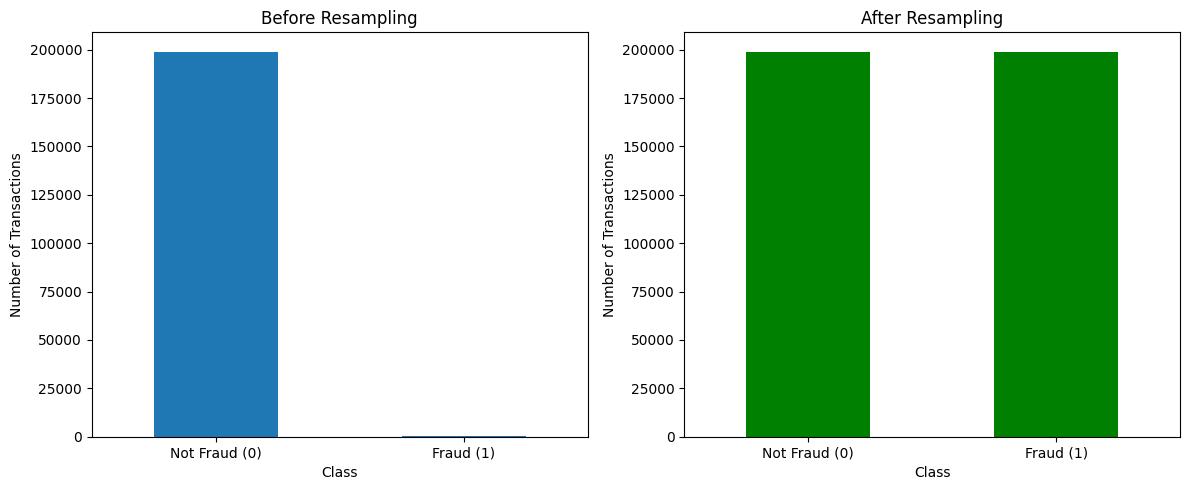

In [9]:
import matplotlib.pyplot as plt

# Before Resampling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().plot(kind='bar', title='Before Resampling', ax=ax1)
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Transactions')
ax1.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'], rotation=0)

# After Resampling
y_train_res.value_counts().plot(kind='bar', title='After Resampling', ax=ax2, color='green')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Transactions')
ax2.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'], rotation=0)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_res, y_train_res)

RandomForestClassifier(random_state=42)

In [11]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate predictions
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Fraud", "Fraud"]))

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     85295
       Fraud       0.88      0.80      0.84       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



## Step 7: Testing Interface

A command-line based testing interface is implemented where users can manually input values for each feature (`V1` to `V28`, `Amount`, and `Time`). The entered values are converted into a format that the trained model can predict on. Based on the model's prediction, a message is printed indicating whether the transaction is **fraudulent** or **legitimate**. This function enhances the usability of the model for real-world applications or demos.


In [16]:
def test_transaction():
    print("\n Fraud Detection System: Manual Test\n")
    print("Enter values for a test transaction:")
    
    # Sample features: replace with actual ones from your dataset (e.g., V1 to V28 + Amount + Time)
    feature_names = X.columns.tolist()

    # Input feature values from user
    values = []
    for feature in feature_names:
        val = float(input(f"Enter value for {feature}: "))
        values.append(val)

    # Convert input to proper format and predict
    input_data = np.array(values).reshape(1, -1)
    prediction = model.predict(input_data)

    # Output result
    if prediction[0] == 1:
        print("\n Fraud Transcation")
    else:
        print("\n Legit Transaction")


In [17]:
test_transaction()


 Fraud Detection System: Manual Test

Enter values for a test transaction:


Enter value for Time:  1.1
Enter value for V1:  1.22
Enter value for V2:  1.2
Enter value for V3:  0.1
Enter value for V4:  0.01
Enter value for V5:  1.5
Enter value for V6:  -1.1
Enter value for V7:  -2
Enter value for V8:  0.9
Enter value for V9:  0.24
Enter value for V10:  1.4
Enter value for V11:  1.1
Enter value for V12:  2.1
Enter value for V13:  -0.9
Enter value for V14:  -0.11
Enter value for V15:  -0.5
Enter value for V16:  -0.32
Enter value for V17:  1.2
Enter value for V18:  1.1
Enter value for V19:  0.01
Enter value for V20:  0.21
Enter value for V21:  0.25
Enter value for V22:  1.39
Enter value for V23:  -0.98
Enter value for V24:  -0.31
Enter value for V25:  -1
Enter value for V26:  1.2
Enter value for V27:  0.2
Enter value for V28:  0.3
Enter value for Amount:  377.99



 Legit Transaction


C:\Users\PMLS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
